In [1]:
%pip install pandas numpy matplotlib scikit-learn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\Firaol Tegenu\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
print(f"Pandas version: {pd.__version__}")

Pandas version: 3.0.2


Model Evaluation:
Mean Absolute Error (MAE): $1727.67
Root Mean Squared Error (RMSE): $2434.36


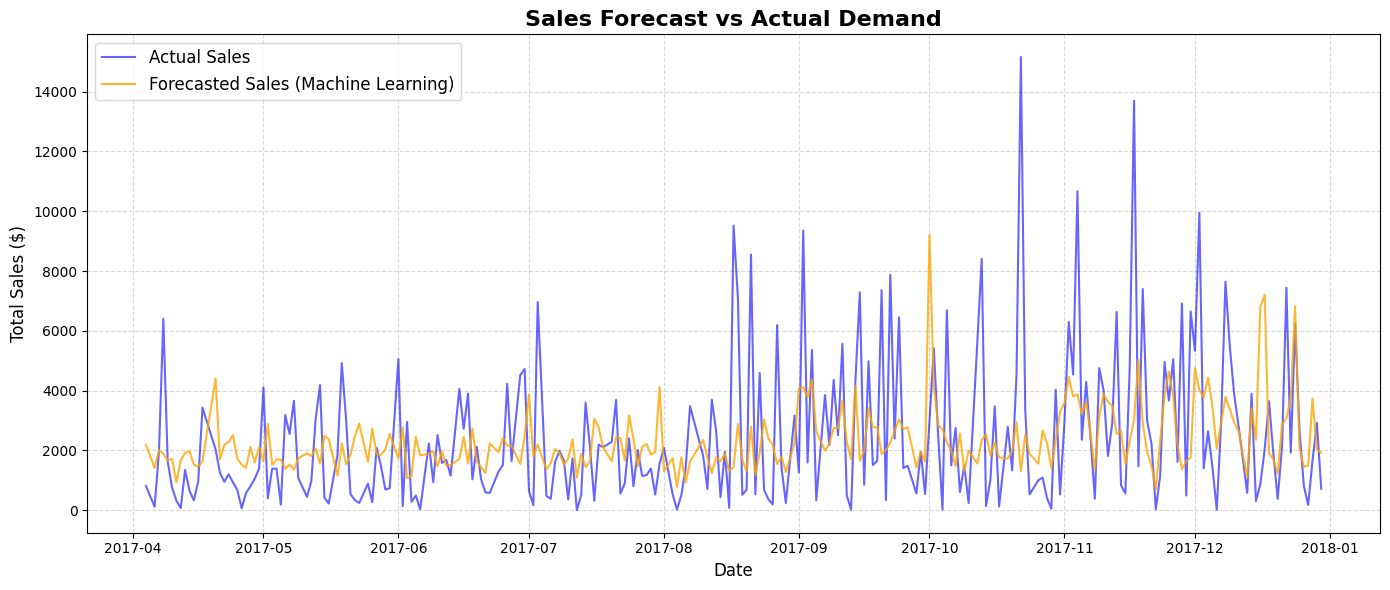

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ==========================================
# Step 1: Load and Clean the Data
# ==========================================
# Load the dataset (Replace 'superstore.csv' with your actual file path)
# Assuming the dataset has 'Order Date' and 'Sales' columns
df = pd.read_csv('Sample - Superstore.csv', encoding='windows-1252')

# Convert 'Order Date' to standard datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Drop rows with missing sales or dates
df = df.dropna(subset=['Order Date', 'Sales'])

# Aggregate sales to a daily level (summing up all transactions per day)
daily_sales = df.groupby('Order Date')['Sales'].sum().reset_index()
daily_sales = daily_sales.sort_values('Order Date')

# ==========================================
# Step 2: Time-Based Feature Engineering
# ==========================================
# Create features based on the date to capture trends and seasonality
daily_sales['Year'] = daily_sales['Order Date'].dt.year
daily_sales['Month'] = daily_sales['Order Date'].dt.month
daily_sales['Day'] = daily_sales['Order Date'].dt.day
daily_sales['DayOfWeek'] = daily_sales['Order Date'].dt.dayofweek
daily_sales['Quarter'] = daily_sales['Order Date'].dt.quarter

# Create a "Lag" feature (Sales from the previous day) to help the model learn continuity
daily_sales['Previous_Day_Sales'] = daily_sales['Sales'].shift(1)

# Drop the first row since it won't have a previous day's sales value
daily_sales = daily_sales.dropna()

# ==========================================
# Step 3: Train-Test Split (Chronological)
# ==========================================
# For time series, we cannot split randomly. We must train on the past and test on the future.
features = ['Year', 'Month', 'Day', 'DayOfWeek', 'Quarter', 'Previous_Day_Sales']
X = daily_sales[features]
y = daily_sales['Sales']

# Split: First 80% of time for training, last 20% for testing
split_index = int(len(daily_sales) * 0.8)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]
dates_test = daily_sales['Order Date'][split_index:]

# ==========================================
# Step 4: Train the Forecasting Model
# ==========================================
# Using Random Forest, which is great at capturing non-linear trends and seasonality
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# ==========================================
# Step 5: Evaluate Model Performance
# ==========================================
predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print(f"Model Evaluation:")
print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")

# ==========================================
# Step 6: Business-Friendly Visualization
# ==========================================
plt.figure(figsize=(14, 6))

# Plot actual vs predicted sales
plt.plot(dates_test, y_test, label='Actual Sales', color='blue', alpha=0.6)
plt.plot(dates_test, predictions, label='Forecasted Sales (Machine Learning)', color='orange', alpha=0.8)

# Formatting the chart for stakeholders
plt.title('Sales Forecast vs Actual Demand', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Show the plot
plt.tight_layout()
plt.show()